# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

### Análisis de los hallazgos

El archivo contiene 271.116 registros y 15 variables. Al revisar los tipos de datos se encuentran variables numéricas, como `Age`, `Height`, `Weight` y `Year`, y variables categóricas relacionadas con el atleta y el evento.

`ID` se descarta porque funciona como identificador. `Games` se considera redundante porque representa una combinación de año y temporada. `Event` tiene una cardinalidad muy alta y además representa un nivel muy específico del deporte, por lo que no se considera conveniente para esta primera etapa.

Los registros duplicados se eliminan antes de continuar. Para `Medal`, los valores nulos se reemplazan por `No medal`. Para las variables predictoras que todavía tengan valores faltantes, la imputación se realizará dentro del `Pipeline`, evitando hacerla antes de separar entrenamiento y prueba.

La variable que se quiere predecir es `Weight`, por lo que los registros donde `Weight` es desconocido no se pueden utilizar para entrenar el modelo.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)

df = pd.read_csv("athlete_events.csv")

print("Dimensiones iniciales:", df.shape)
print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))

print("\nValores nulos:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))

print("\nFilas duplicadas:", df.duplicated().sum())

print("\nNúmero de valores diferentes por variable:")
display(df.nunique(dropna=False).sort_values(ascending=False).to_frame("n_unique"))

print("\nPrimeros registros:")
display(df.head())


Dimensiones iniciales: (271116, 15)

Tipos de datos:


,tipo
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,int64



Valores nulos:


,nulos
Medal,231333
Weight,62875
Height,60171
Age,9474
Sex,0
ID,0
Name,0
Team,0
NOC,0
Year,0



Filas duplicadas: 1385

Número de valores diferentes por variable:


,n_unique
ID,135571
Name,134732
Team,1184
Event,765
NOC,230
Weight,221
Height,96
Age,75
Sport,66
Games,51



Primeros registros:


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

### Análisis de las variables categóricas

`Sex`, `Season`, `Sport`, `NOC` y `City` son variables nominales porque sus categorías no tienen un orden. `Medal` también es categórica nominal, con `No medal` como categoría explícita para los valores que estaban vacíos.

`Year` se puede interpretar como una variable ordinal/temporal, ya que sus valores tienen un orden cronológico. En el modelo se conserva como numérica para representar ese orden.

Las variables `Team` y `Sport` presentan muchas categorías, mientras que `Sex` y `Season` tienen pocas. En las variables con alta cardinalidad conviene tener cuidado con One-Hot Encoding porque puede generar muchas columnas. En el segundo modelo se agrega `Sport`, pero no `Team`, para evitar un aumento todavía mayor de dimensionalidad.

Las categorías muy poco frecuentes se consideran atípicas desde el punto de vista de frecuencia, pero no se eliminan automáticamente. Que una categoría tenga pocos registros no significa que sea un error. Para las variables nominales se utiliza One-Hot Encoding y para la variable ordinal/temporal se conserva el orden mediante su representación numérica.


Duplicados eliminados: 70770
Dimensiones después de la limpieza: (200346, 12)


,Variable,Categorías,Nulos
0,Name,134732,0
2,Team,1184,0
3,NOC,230,0
6,Sport,66,0
5,City,42,0
7,Medal,4,0
1,Sex,2,0
4,Season,2,0


,Variable,Categorías < 1%,Ejemplos
0,Name,134732,"[Ole Einar Bjrndalen, Stefania Belmondo, Takas..."
1,Sex,0,[]
2,Team,1153,"[Cuba, East Germany, New Zealand, Ukraine, Yug..."
3,NOC,199,"[GDR, CUB, NZL, UKR, YUG]"
4,Season,0,[]
5,City,14,"[Albertville, Lillehammer, Calgary, Lake Placi..."
6,Sport,36,"[Archery, Table Tennis, Ski Jumping, Luge, Bad..."
7,Medal,0,[]


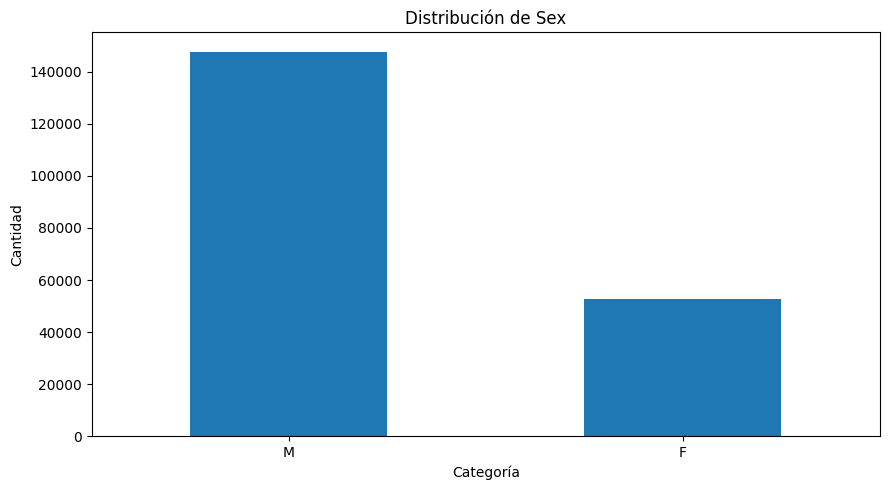

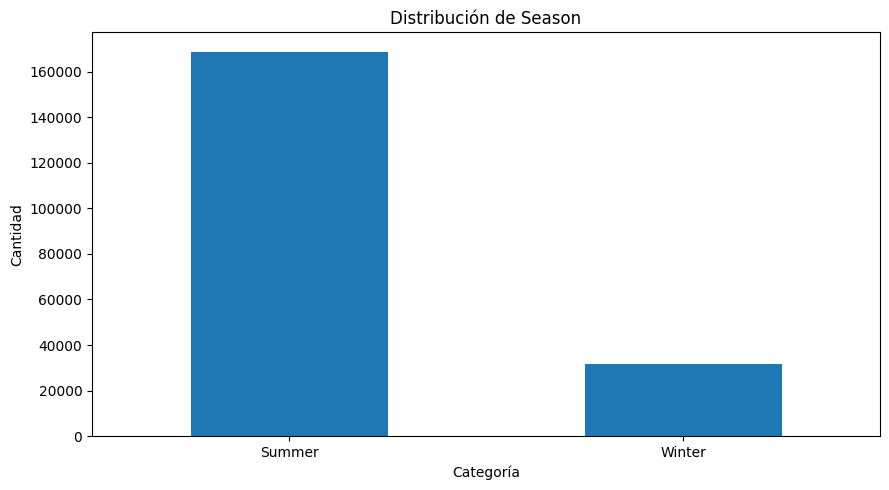

In [ ]:
data = df.copy()

data = data.drop(columns=["ID", "Games", "Event"])

data["Medal"] = data["Medal"].fillna("No medal")

duplicados_antes = data.duplicated().sum()
data = data.drop_duplicates().copy()

print("Duplicados eliminados:", duplicados_antes)
print("Dimensiones después de la limpieza:", data.shape)

categorical_vars = ["Name", "Sex", "Team", "NOC", "Season", "City", "Sport", "Medal"]

cardinality = pd.DataFrame({
    "Variable": categorical_vars,
    "Categorías": [data[v].nunique(dropna=True) for v in categorical_vars],
    "Nulos": [data[v].isna().sum() for v in categorical_vars]
}).sort_values("Categorías", ascending=False)

display(cardinality)

rare_rows = []
for col in categorical_vars:
    freq = data[col].value_counts(normalize=True, dropna=False)
    rare = freq[freq < 0.01]
    rare_rows.append({
        "Variable": col,
        "Categorías < 1%": len(rare),
        "Ejemplos": list(rare.head(5).index)
    })

rare_categories = pd.DataFrame(rare_rows)
display(rare_categories)

fig, ax = plt.subplots(figsize=(9, 5))
data["Sex"].value_counts(dropna=False).plot(kind="bar", ax=ax)
ax.set_title("Distribución de Sex")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
data["Season"].value_counts(dropna=False).plot(kind="bar", ax=ax)
ax.set_title("Distribución de Season")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

### Análisis de las variables cuantitativas

`Age`, `Height`, `Weight` y `Year` tienen comportamientos diferentes. Las gráficas permiten ver que no todas siguen una distribución aproximadamente normal. `Year`, por ejemplo, está formado por años concretos y por eso no se interpreta como una variable continua normalmente distribuida.

`Weight` presenta dispersión y valores alejados del centro. Los valores atípicos detectados mediante IQR no se eliminan de forma automática, porque en un dataset deportivo un peso extremo puede corresponder a un atleta real y a una disciplina específica.

Para el modelo se utiliza imputación por mediana en las variables cuantitativas y posteriormente estandarización. Esta decisión permite trabajar con los valores faltantes sin eliminar innecesariamente registros y deja las variables en una escala comparable.


,count,mean,std,min,25%,50%,75%,max
Age,193248.0,25.814513,6.148940,10.0,22.0,25.0,29.0,97.0
Height,158056.0,176.473661,10.355500,127.0,170.0,176.0,183.0,226.0
Weight,156351.0,72.320350,14.713830,25.0,62.0,71.0,81.0,214.0
Year,200346.0,1979.472333,29.962685,1896.0,1960.0,1988.0,2004.0,2016.0


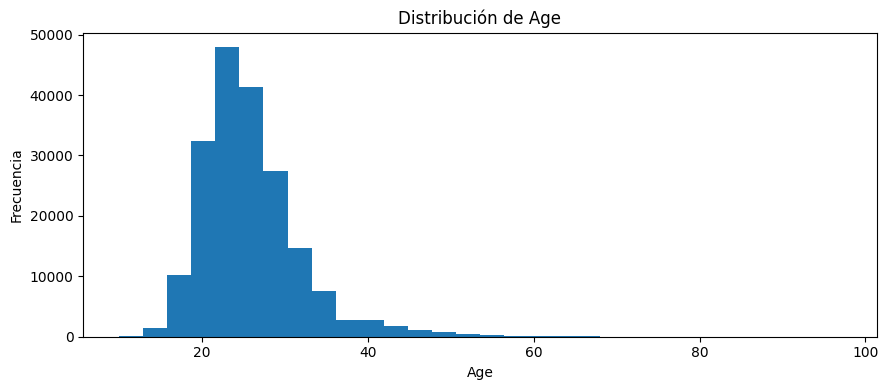

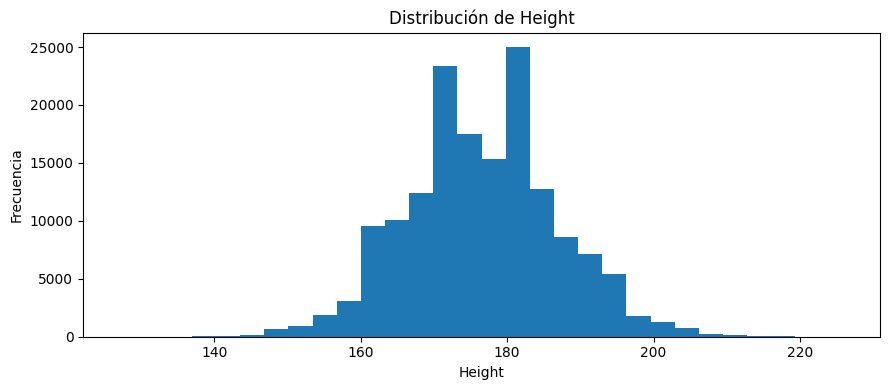

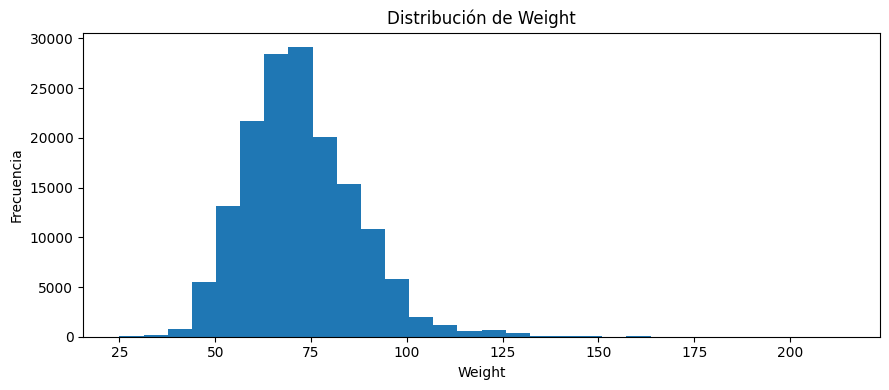

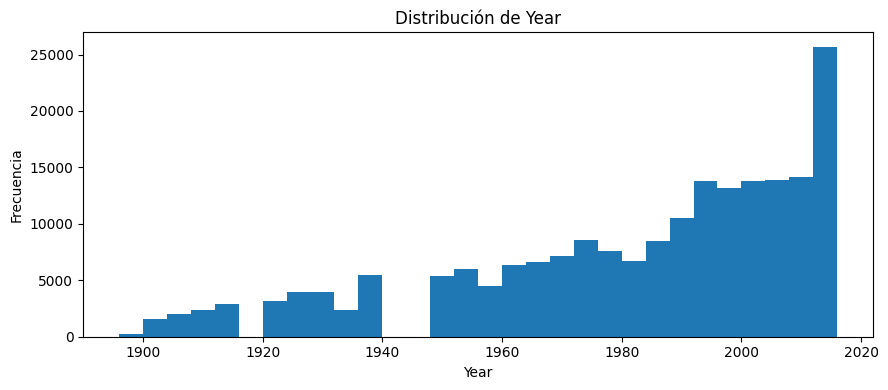

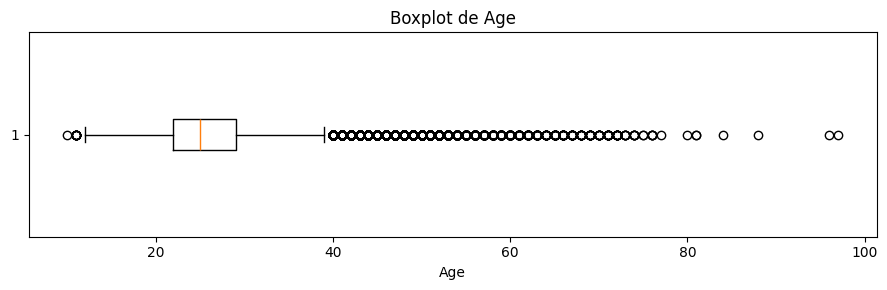

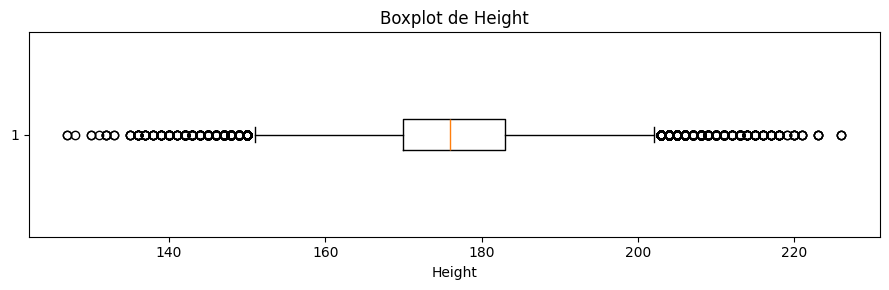

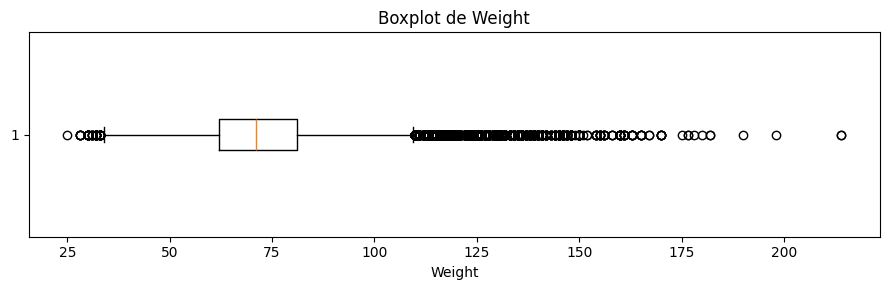

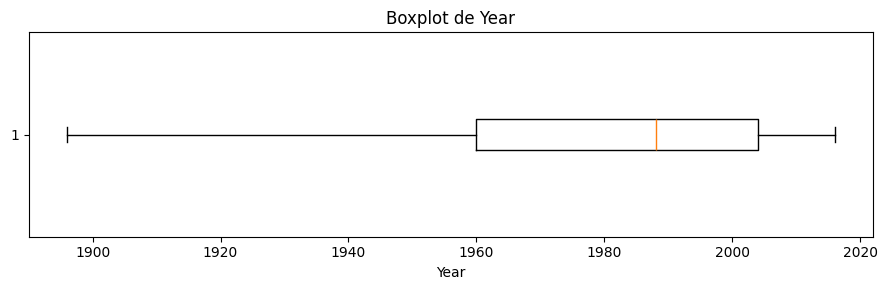

,Variable,Q1,Q3,Límite inferior,Límite superior,Atípicos IQR
0,Age,22.0,29.0,11.5,39.5,6323
1,Height,170.0,183.0,150.5,202.5,2142
2,Weight,62.0,81.0,33.5,109.5,2831
3,Year,1960.0,2004.0,1894.0,2070.0,0


,asimetría
Year,-0.870608
Height,0.070607
Weight,0.841559
Age,1.645075


In [ ]:
quantitative_vars = ["Age", "Height", "Weight", "Year"]

display(data[quantitative_vars].describe().T)

for col in quantitative_vars:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(data[col].dropna(), bins=30)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

for col in quantitative_vars:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.boxplot(data[col].dropna(), vert=False)
    ax.set_title(f"Boxplot de {col}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()

outlier_summary = []
for col in quantitative_vars:
    s = data[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "Límite inferior": lower,
        "Límite superior": upper,
        "Atípicos IQR": n_out
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

skewness = data[quantitative_vars].skew(numeric_only=True).sort_values()
display(skewness.to_frame("asimetría"))


Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

### Análisis bivariado

La relación más clara con `Weight` se espera en `Height`, porque la altura tiene una relación física directa con el peso. `Age` puede aportar información, pero la dispersión muestra que atletas de edades parecidas pueden tener pesos muy diferentes.

`Sex` permite observar diferencias en la distribución del peso entre sus categorías. `Season` puede aportar información adicional, aunque su relación con el peso es menos directa. `Sport` resulta especialmente interesante porque las exigencias físicas cambian de una disciplina a otra.

Por esta razón, para el primer modelo se seleccionan `Height`, `Age`, `Year`, `Sex` y `Season`. Se incluyen tres variables cuantitativas/ordenadas y dos nominales, cumpliendo la condición de tener al menos una característica ordinal y dos nominales. En el segundo modelo se agregan `Sport` y `NOC` para comprobar si la información deportiva y del comité nacional mejora la predicción.


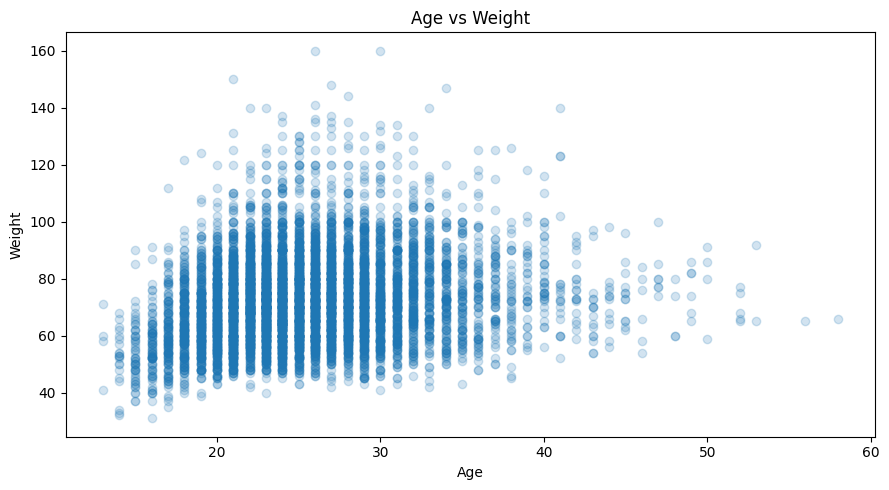

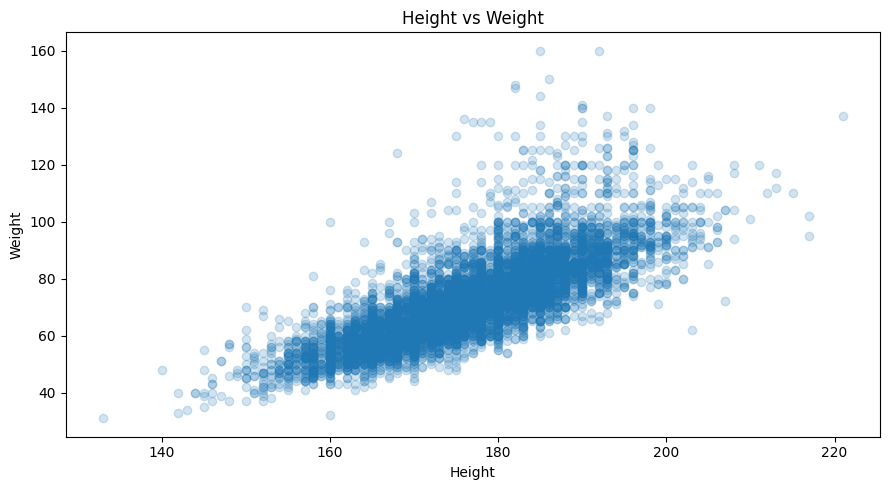

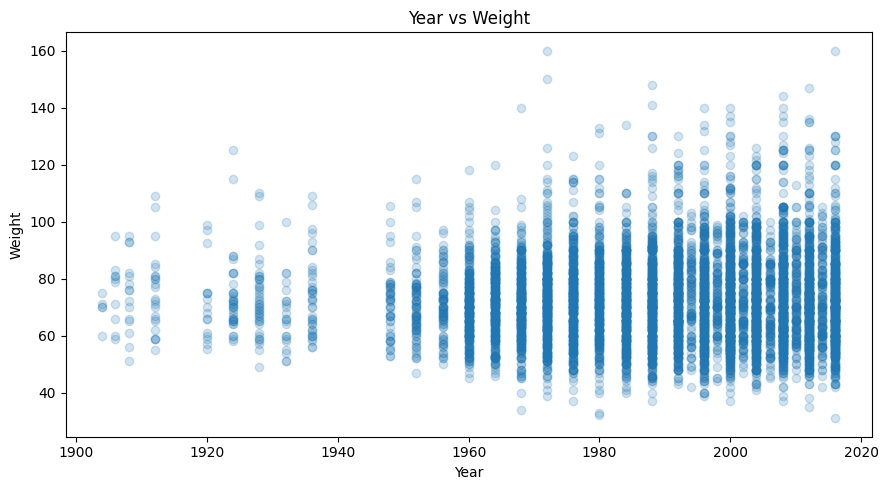

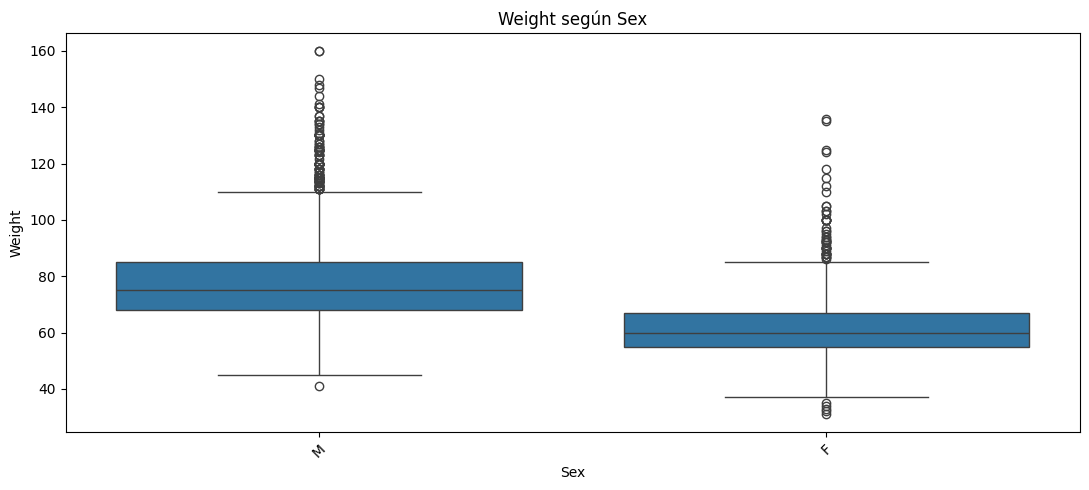

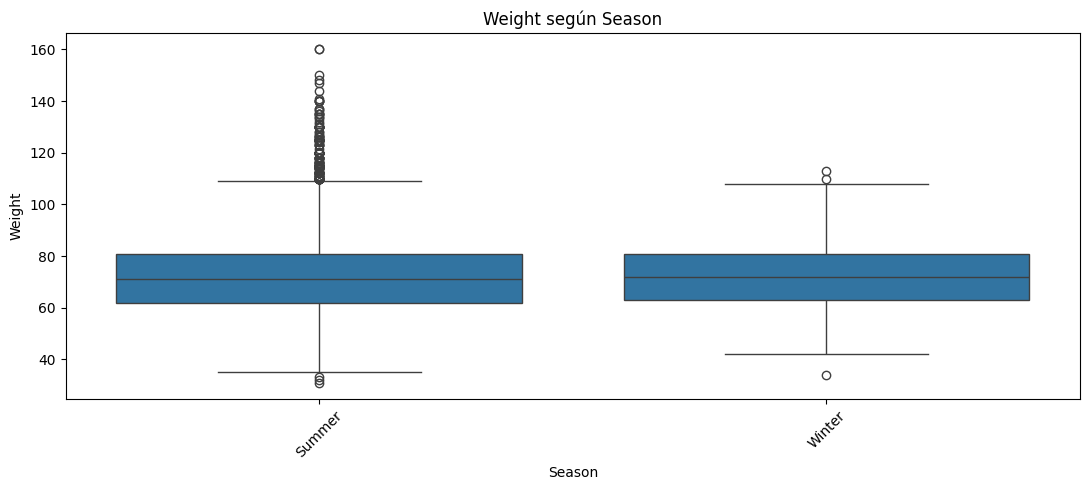

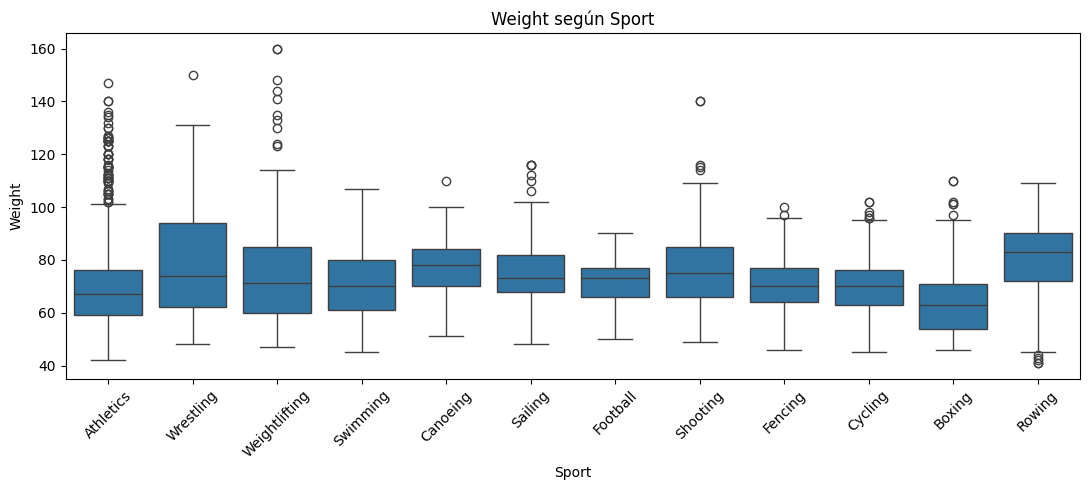

,correlación con Weight
Weight,1.000000
Height,0.775418
Age,0.164508
Year,0.002012


In [ ]:
target = "Weight"

bivar = data.dropna(subset=[target]).sample(
    n=min(8000, data[target].notna().sum()),
    random_state=1
)

for col in ["Age", "Height", "Year"]:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(bivar[col], bivar[target], alpha=0.20)
    ax.set_title(f"{col} vs Weight")
    ax.set_xlabel(col)
    ax.set_ylabel("Weight")
    plt.tight_layout()
    plt.show()

for col in ["Sex", "Season", "Sport"]:
    plot_data = bivar.copy()
    if col == "Sport":
        top = plot_data["Sport"].value_counts().head(12).index
        plot_data = plot_data[plot_data["Sport"].isin(top)]

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=plot_data, x=col, y=target, ax=ax)
    ax.set_title(f"Weight según {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Weight")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

corr = data[["Age", "Height", "Year", "Weight"]].corr()["Weight"].sort_values(ascending=False)
display(corr.to_frame("correlación con Weight"))


## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

### Nota sobre el modelo solicitado

Hay una inconsistencia en la consigna: al comienzo se indica que `Weight` es una variable cuantitativa y que el modelo debe seleccionarse teniendo esto en cuenta, pero posteriormente se menciona **regresión logística**. `LogisticRegression` es un algoritmo de clasificación y necesita una variable objetivo categórica, mientras que `Weight` es continua.

Por ese motivo se utiliza **`LinearRegression`**, que sí corresponde a una variable objetivo numérica como `Weight`. De esta manera no se cambia artificialmente el objetivo para convertirlo en clases y se mantiene el propósito inicial de la evaluación.

El procesamiento sigue el flujo trabajado en clase: `ColumnTransformer` separa el tratamiento de variables numéricas y categóricas, y `Pipeline` integra todo el procesamiento con el modelo. Se utiliza `remainder='drop'` para que únicamente entren al modelo las cinco características seleccionadas.


In [ ]:
features_1 = ["Height", "Age", "Year", "Sex", "Season"]
target = "Weight"

model_data = data[features_1 + [target]].copy()

model_data = model_data.dropna(subset=[target])

X = model_data[features_1]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=1
)

numeric_features = ["Height", "Age", "Year"]

nominal_features = ["Sex", "Season"]

numeric_processor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

nominal_processor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="if_binary",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", numeric_processor, numeric_features),
        ("nominales", nominal_processor, nominal_features)
    ],
    remainder="drop"
)

pipeline_1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipeline_1.fit(X_train, y_train)

score_train_1 = pipeline_1.score(X_train, y_train)
score_test_1 = pipeline_1.score(X_test, y_test)

print("Score de entrenamiento:", round(score_train_1, 4))
print("Score de prueba:", round(score_test_1, 4))

feature_names_1 = pipeline_1.named_steps["preprocessor"].get_feature_names_out()

print("\nCaracterísticas realmente utilizadas por el modelo 1:")
for feature in feature_names_1:
    print(feature)

print("\nCantidad final de características:", len(feature_names_1))

pred_test_1 = pipeline_1.predict(X_test)
print("\nMAE:", round(mean_absolute_error(y_test, pred_test_1), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_test_1)), 2))


Score de entrenamiento: 0.6226
Score de prueba: 0.6252

Características realmente utilizadas por el modelo 1:
numericas__Height
numericas__Age
numericas__Year
nominales__Sex_M
nominales__Season_Winter

Cantidad final de características: 5

MAE: 6.27
RMSE: 8.97


Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

### Análisis del reentrenamiento

En el segundo modelo se agregan `Sport` y `NOC`. Esto permite comprobar si conocer la disciplina y el comité nacional aporta información adicional para predecir el peso.

La comparación se hace principalmente con el **score de prueba (R²)**. Un aumento del score de prueba indicaría una mejora en la capacidad de generalización. También se revisan MAE y RMSE para comprobar si el error de predicción disminuye.

El número de características finales aumenta porque las variables nominales pasan por One-Hot Encoding. Por eso las características reportadas al final son las que realmente recibe el modelo después del procesamiento y no solamente los nombres originales de las columnas.


Score de entrenamiento: 0.7007
Score de prueba: 0.698

Características realmente utilizadas por el modelo 2:
numericas__Height
numericas__Age
numericas__Year
nominales__Sex_M
nominales__Season_Winter
nominales__Sport_Alpine Skiing
nominales__Sport_Archery
nominales__Sport_Art Competitions
nominales__Sport_Athletics
nominales__Sport_Badminton
nominales__Sport_Baseball
nominales__Sport_Basketball
nominales__Sport_Beach Volleyball
nominales__Sport_Biathlon
nominales__Sport_Bobsleigh
nominales__Sport_Boxing
nominales__Sport_Canoeing
nominales__Sport_Cross Country Skiing
nominales__Sport_Curling
nominales__Sport_Cycling
nominales__Sport_Diving
nominales__Sport_Equestrianism
nominales__Sport_Fencing
nominales__Sport_Figure Skating
nominales__Sport_Football
nominales__Sport_Freestyle Skiing
nominales__Sport_Golf
nominales__Sport_Gymnastics
nominales__Sport_Handball
nominales__Sport_Hockey
nominales__Sport_Ice Hockey
nominales__Sport_Judo
nominales__Sport_Lacrosse
nominales__Sport_Luge
nominal

/opt/pyvenv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/pyvenv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Modelo,Score entrenamiento,Score prueba,MAE prueba,RMSE prueba
0,Modelo 1,0.6226,0.6252,6.2657,8.9715
1,Modelo 2,0.7007,0.6980,5.5729,8.0538


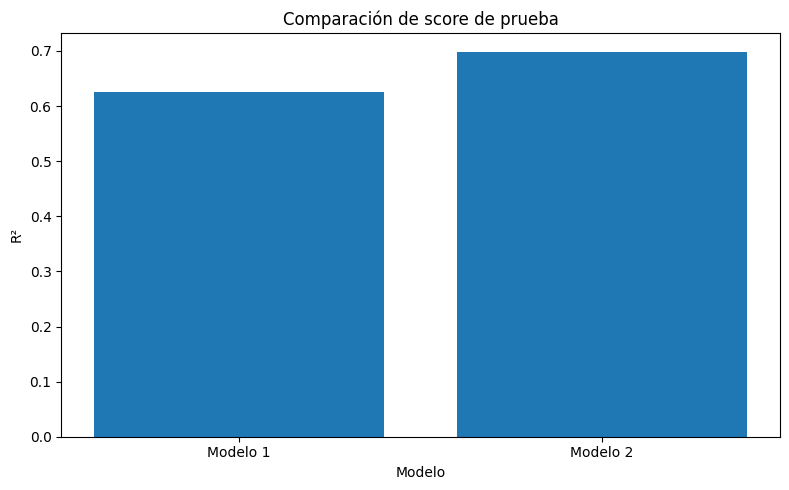

In [ ]:
features_2 = ["Height", "Age", "Year", "Sex", "Season", "Sport", "NOC"]

model_data_2 = data[features_2 + [target]].copy()
model_data_2 = model_data_2.dropna(subset=[target])

X2 = model_data_2[features_2]
y2 = model_data_2[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.20,
    random_state=1
)

numeric_features_2 = ["Height", "Age", "Year"]
nominal_features_2 = ["Sex", "Season", "Sport", "NOC"]

numeric_processor_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

nominal_processor_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="if_binary",
        sparse_output=False
    ))
])

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("numericas", numeric_processor_2, numeric_features_2),
        ("nominales", nominal_processor_2, nominal_features_2)
    ],
    remainder="drop"
)

pipeline_2 = Pipeline(steps=[
    ("preprocessor", preprocessor_2),
    ("model", LinearRegression())
])

pipeline_2.fit(X2_train, y2_train)

score_train_2 = pipeline_2.score(X2_train, y2_train)
score_test_2 = pipeline_2.score(X2_test, y2_test)

print("Score de entrenamiento:", round(score_train_2, 4))
print("Score de prueba:", round(score_test_2, 4))

feature_names_2 = pipeline_2.named_steps["preprocessor"].get_feature_names_out()

print("\nCaracterísticas realmente utilizadas por el modelo 2:")
for feature in feature_names_2:
    print(feature)

print("\nCantidad final de características:", len(feature_names_2))

pred_test_2 = pipeline_2.predict(X2_test)
print("\nMAE:", round(mean_absolute_error(y2_test, pred_test_2), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y2_test, pred_test_2)), 2))

comparacion = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Score entrenamiento": [score_train_1, score_train_2],
    "Score prueba": [score_test_1, score_test_2],
    "MAE prueba": [
        mean_absolute_error(y_test, pred_test_1),
        mean_absolute_error(y2_test, pred_test_2)
    ],
    "RMSE prueba": [
        np.sqrt(mean_squared_error(y_test, pred_test_1)),
        np.sqrt(mean_squared_error(y2_test, pred_test_2))
    ]
})

display(comparacion.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(comparacion["Modelo"], comparacion["Score prueba"])
ax.set_title("Comparación de score de prueba")
ax.set_ylabel("R²")
ax.set_xlabel("Modelo")
plt.tight_layout()
plt.show()
